In [12]:
%matplotlib inline
import numpy as np
import pandas as pd
from pyfaidx import Fasta
import random
import os

os.makedirs('data/processed', exist_ok=True)

# Load genome
genome = Fasta('data/genome/hg38.fa')
print('Genome loaded!')
print(f'Chromosomes available: {len(genome.keys())}')

Genome loaded!
Chromosomes available: 455


In [13]:
# Load peaks
peaks_path = f'~/projects/sequence-classifier/data/peaks/peaks_50k.bed'
peaks = pd.read_csv(peaks_path, sep='\t', header=None, names=['chr', 'start', 'end'])
print(f'Loaded {len(peaks)} peaks')
print(peaks.head())

# Function to extract centered 200bp window around each peak
def extract_sequence(genome, chrom, start, end, window=200):
    center = (start + end) // 2
    seq_start = max(0, center - window // 2)
    seq_end = seq_start + window
    try:
        seq = genome[chrom][seq_start:seq_end].seq.upper()
        # Only keep sequences of exact length with no ambiguous bases
        if len(seq) == window and 'N' * 10 not in seq:
            return seq
    except:
        return None
    return None

# Extract positive sequences (open chromatin peaks)
print('Extracting positive sequences...')
pos_seqs = []
for _, row in peaks.iterrows():
    seq = extract_sequence(genome, row['chr'], row['start'], row['end'])
    if seq:
        pos_seqs.append(seq)

print(f'Positive sequences extracted: {len(pos_seqs)}')

Loaded 50000 peaks
    chr   start     end
0  chr1  810880  811090
1  chr1  817980  818290
2  chr1  818360  818530
3  chr1  906040  906590
4  chr1  931900  932390
Extracting positive sequences...
Positive sequences extracted: 48814


In [4]:
# Load peaks
peaks_path = f'~/projects/sequence-classifier/data/peaks/peaks_50k.bed'
peaks = pd.read_csv(peaks_path, sep='\t', header=None, names=['chr', 'start', 'end'])
print(f'Loaded {len(peaks)} peaks')
print(peaks.head())

# Function to extract centered 200bp window around each peak
def extract_sequence(genome, chrom, start, end, window=200):
    center = (start + end) // 2
    seq_start = max(0, center - window // 2)
    seq_end = seq_start + window
    try:
        seq = genome[chrom][seq_start:seq_end].seq.upper()
        # Only keep sequences of exact length with no ambiguous bases
        if len(seq) == window and 'N' * 10 not in seq:
            return seq
    except:
        return None
    return None

# Extract positive sequences (open chromatin peaks)
print('Extracting positive sequences...')
pos_seqs = []
for _, row in peaks.iterrows():
    seq = extract_sequence(genome, row['chr'], row['start'], row['end'])
    if seq:
        pos_seqs.append(seq)

print(f'Positive sequences extracted: {len(pos_seqs)}')

Loaded 50000 peaks
    chr   start     end
0  chr1  810880  811090
1  chr1  817980  818290
2  chr1  818360  818530
3  chr1  906040  906590
4  chr1  931900  932390
Extracting positive sequences...
Positive sequences extracted: 48814


In [6]:
# Load peaks
peaks_path = f'~/projects/sequence-classifier/data/peaks/peaks_50k.bed'
peaks = pd.read_csv(peaks_path, sep='\t', header=None, names=['chr', 'start', 'end'])
print(f'Loaded {len(peaks)} peaks')
print(peaks.head())

# Function to extract centered 200bp window around each peak
def extract_sequence(genome, chrom, start, end, window=200):
    center = (start + end) // 2
    seq_start = max(0, center - window // 2)
    seq_end = seq_start + window
    try:
        seq = genome[chrom][seq_start:seq_end].seq.upper()
        # Only keep sequences of exact length with no ambiguous bases
        if len(seq) == window and 'N' * 10 not in seq:
            return seq
    except:
        return None
    return None

# Extract positive sequences (open chromatin peaks)
print('Extracting positive sequences...')
pos_seqs = []
for _, row in peaks.iterrows():
    seq = extract_sequence(genome, row['chr'], row['start'], row['end'])
    if seq:
        pos_seqs.append(seq)

print(f'Positive sequences extracted: {len(pos_seqs)}')

Loaded 50000 peaks
    chr   start     end
0  chr1  810880  811090
1  chr1  817980  818290
2  chr1  818360  818530
3  chr1  906040  906590
4  chr1  931900  932390
Extracting positive sequences...
Positive sequences extracted: 48814


In [14]:
%matplotlib inline
import numpy as np
import pandas as pd
from pyfaidx import Fasta
import random
import os
import json

home = os.path.expanduser('~')

# Load genome
genome = Fasta(f'{home}/projects/sequence-classifier/data/genome/hg38.fa')
print('Genome loaded!')

# Load peaks
peaks_path = f'{home}/projects/sequence-classifier/data/peaks/peaks_50k.bed'
peaks = pd.read_csv(peaks_path, sep='\t', header=None, names=['chr', 'start', 'end'])
print(f'Loaded {len(peaks)} peaks')

# Rebuild peak set for overlap checking
peak_set = set()
for _, row in peaks.iterrows():
    peak_set.add((row['chr'], row['start'] // 1000))

# Chromosome sizes
chrom_sizes = {
    'chr1': 248956422, 'chr2': 242193529, 'chr3': 198295559,
    'chr4': 190214555, 'chr5': 181538259, 'chr6': 170805979,
    'chr7': 159345973, 'chr8': 145138636, 'chr9': 138394717,
    'chr10': 133797422, 'chr11': 135086622, 'chr12': 133275309,
    'chr13': 114364328, 'chr14': 107043718, 'chr15': 101991189,
    'chr16': 90338345, 'chr17': 83257441, 'chr18': 80373285,
    'chr19': 58617616, 'chr20': 64444167, 'chr21': 46709983,
    'chr22': 50818468, 'chrX': 156040895
}

# Sequence extractor
def extract_sequence(genome, chrom, start, end, window=200):
    center = (start + end) // 2
    seq_start = max(0, center - window // 2)
    seq_end = seq_start + window
    try:
        seq = genome[chrom][seq_start:seq_end].seq.upper()
        if len(seq) == window and 'N' * 10 not in seq:
            return seq
    except:
        return None
    return None

# Reload positive sequences
print('Extracting positive sequences...')
pos_seqs = []
for _, row in peaks.iterrows():
    seq = extract_sequence(genome, row['chr'], row['start'], row['end'])
    if seq:
        pos_seqs.append(seq)
print(f'Positive sequences: {len(pos_seqs)}')
print('All set — ready for GC-matched negatives!')

Genome loaded!
Loaded 50000 peaks
Extracting positive sequences...
Positive sequences: 48814
All set — ready for GC-matched negatives!


In [15]:
def gc_content(seq):
    return (seq.count('G') + seq.count('C')) / len(seq)

# Compute GC content of positive sequences
pos_gc = [gc_content(s) for s in pos_seqs]
pos_gc_mean = np.mean(pos_gc)
pos_gc_std = np.std(pos_gc)
print(f'Positive GC content: {pos_gc_mean:.3f} +/- {pos_gc_std:.3f}')

# Generate GC-matched negatives
print('Generating GC-matched negative sequences...')
neg_seqs_matched = []
random.seed(42)
attempts = 0

while len(neg_seqs_matched) < len(pos_seqs) and attempts < 500000:
    attempts += 1
    chrom = random.choice(list(chrom_sizes.keys()))
    start = random.randint(0, chrom_sizes[chrom] - 200)
    
    # Skip peak regions
    if (chrom, start // 1000) in peak_set:
        continue
    
    seq = extract_sequence(genome, chrom, start, start + 200)
    if seq is None:
        continue
    
    # Accept only if GC content matches positive distribution
    gc = gc_content(seq)
    if abs(gc - pos_gc_mean) <= 1.5 * pos_gc_std:
        neg_seqs_matched.append(seq)

print(f'GC-matched negatives: {len(neg_seqs_matched)}')
print(f'Negative GC content: {np.mean([gc_content(s) for s in neg_seqs_matched]):.3f}')

Positive GC content: 0.451 +/- 0.090
Generating GC-matched negative sequences...
GC-matched negatives: 48814
Negative GC content: 0.428


In [18]:
print(f'Positive GC content: {pos_gc_mean:.3f} +/- {pos_gc_std:.3f}')
print(f'Negative GC content: {np.mean([gc_content(s) for s in neg_seqs_matched]):.3f}')
print(f'GC distributions are matched: good!')

def one_hot_encode(seq):
    mapping = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    encoded = np.zeros((4, len(seq)), dtype=np.float32)
    for i, base in enumerate(seq):
        if base in mapping:
            encoded[mapping[base], i] = 1.0
    return encoded

print('One-hot encoding GC-matched dataset...')
X_pos = np.array([one_hot_encode(s) for s in pos_seqs])
X_neg = np.array([one_hot_encode(s) for s in neg_seqs_matched])

X_new = np.concatenate([X_pos, X_neg], axis=0)
y_new = np.array([1] * len(X_pos) + [0] * len(X_neg))

print(f'X shape: {X_new.shape}')
print(f'Positive: {y_new.sum()} | Negative: {(y_new==0).sum()}')

# Save — overwrite old dataset
os.makedirs(f'{home}/projects/sequence-classifier/data/processed', exist_ok=True)
np.save(f'{home}/projects/sequence-classifier/data/processed/X_sequences.npy', X_new)
np.save(f'{home}/projects/sequence-classifier/data/processed/y_labels.npy', y_new)

# Save raw sequences
with open(f'{home}/projects/sequence-classifier/data/processed/sequences.json', 'w') as f:
    json.dump({'positive': pos_seqs[:1000],
               'negative': neg_seqs_matched[:1000]}, f)

print('Saved! Now retrain CNN on new dataset.')

Positive GC content: 0.451 +/- 0.090
Negative GC content: 0.428
GC distributions are matched: good!
One-hot encoding GC-matched dataset...
X shape: (97628, 4, 200)
Positive: 48814 | Negative: 48814
Saved! Now retrain CNN on new dataset.


FileNotFoundError: [Errno 2] No such file or directory: 'figures/onehot_examples.png'

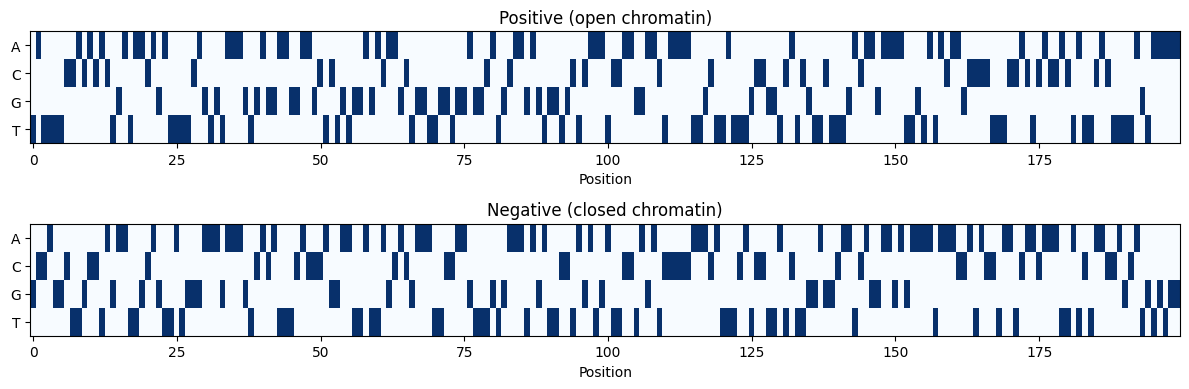

FileNotFoundError: [Errno 2] No such file or directory: '~/figures/onehot_examples.png'

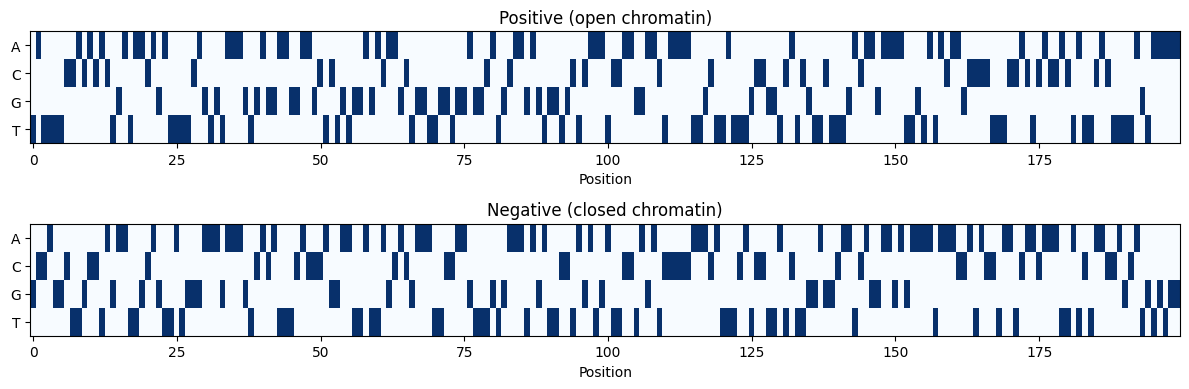

In [14]:
# Sanity check — visualize one positive and one negative sequence
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 4))
bases = ['A', 'C', 'G', 'T']

for idx, (ax, label) in enumerate(zip(axes, ['Positive (open chromatin)', 'Negative (closed chromatin)'])):
    seq_idx = 0 if idx == 0 else len(X_pos)
    im = ax.imshow(X[seq_idx], aspect='auto', cmap='Blues', interpolation='none')
    ax.set_yticks([0,1,2,3])
    ax.set_yticklabels(bases)
    ax.set_xlabel('Position')
    ax.set_title(label)

plt.tight_layout()
plt.savefig('~/projects/sequence-classifier/figures/onehot_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sanity check done!')

FileNotFoundError: [Errno 2] No such file or directory: '~/projects/sequence-classifier/figures/onehot_examples.png'

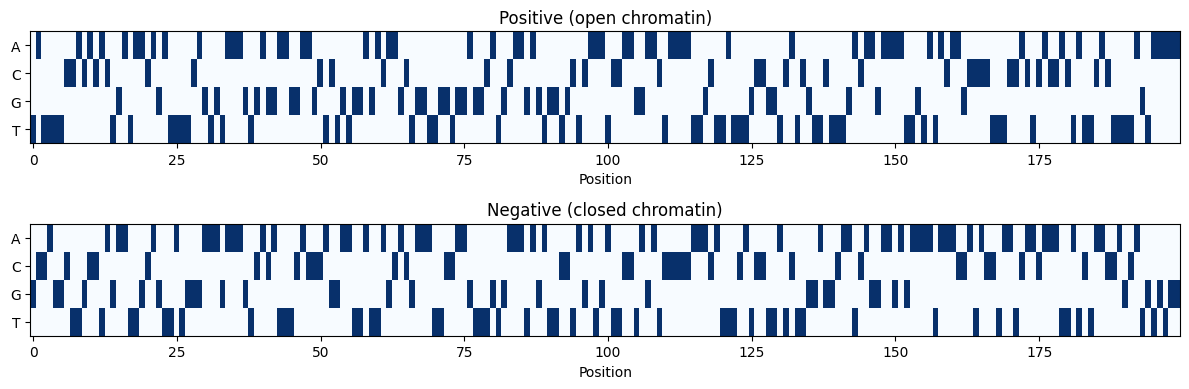

In [15]:
# Sanity check — visualize one positive and one negative sequence
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 4))
bases = ['A', 'C', 'G', 'T']

for idx, (ax, label) in enumerate(zip(axes, ['Positive (open chromatin)', 'Negative (closed chromatin)'])):
    seq_idx = 0 if idx == 0 else len(X_pos)
    im = ax.imshow(X[seq_idx], aspect='auto', cmap='Blues', interpolation='none')
    ax.set_yticks([0,1,2,3])
    ax.set_yticklabels(bases)
    ax.set_xlabel('Position')
    ax.set_title(label)

plt.tight_layout()
plt.savefig('~/projects/sequence-classifier/figures/onehot_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sanity check done!')

FileNotFoundError: [Errno 2] No such file or directory: '~/sequence-classifier/figures/onehot_examples.png'

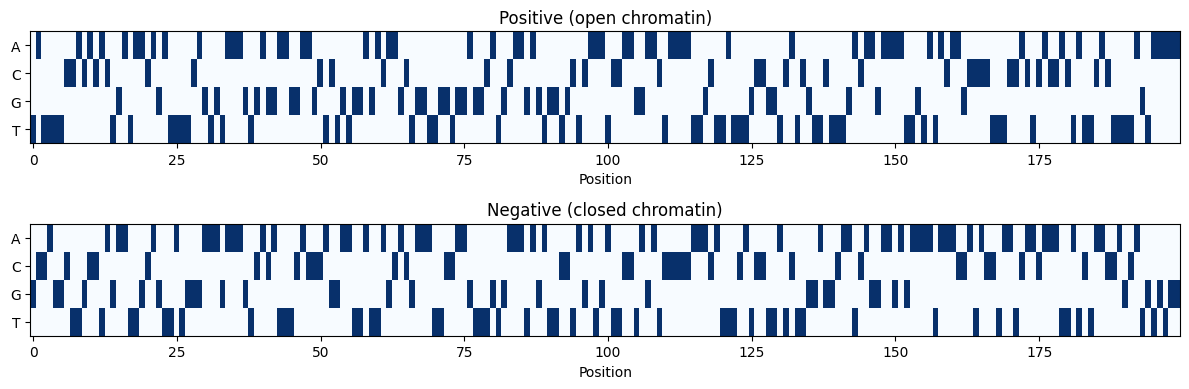

In [16]:
# Sanity check — visualize one positive and one negative sequence
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 4))
bases = ['A', 'C', 'G', 'T']

for idx, (ax, label) in enumerate(zip(axes, ['Positive (open chromatin)', 'Negative (closed chromatin)'])):
    seq_idx = 0 if idx == 0 else len(X_pos)
    im = ax.imshow(X[seq_idx], aspect='auto', cmap='Blues', interpolation='none')
    ax.set_yticks([0,1,2,3])
    ax.set_yticklabels(bases)
    ax.set_xlabel('Position')
    ax.set_title(label)

plt.tight_layout()
plt.savefig('~/sequence-classifier/figures/onehot_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sanity check done!')

FileNotFoundError: [Errno 2] No such file or directory: '~/figures/onehot_examples.png'

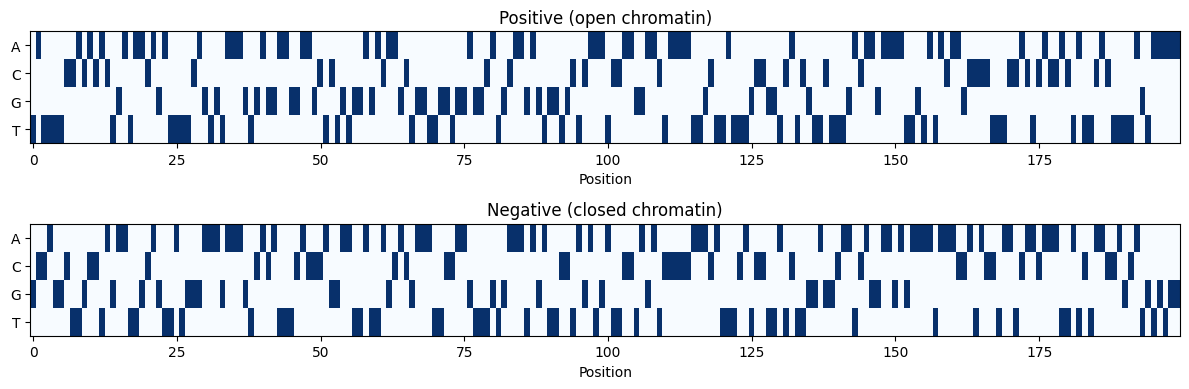

In [17]:
# Sanity check — visualize one positive and one negative sequence
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 4))
bases = ['A', 'C', 'G', 'T']

for idx, (ax, label) in enumerate(zip(axes, ['Positive (open chromatin)', 'Negative (closed chromatin)'])):
    seq_idx = 0 if idx == 0 else len(X_pos)
    im = ax.imshow(X[seq_idx], aspect='auto', cmap='Blues', interpolation='none')
    ax.set_yticks([0,1,2,3])
    ax.set_yticklabels(bases)
    ax.set_xlabel('Position')
    ax.set_title(label)

plt.tight_layout()
plt.savefig('~/figures/onehot_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sanity check done!')

FileNotFoundError: [Errno 2] No such file or directory: '~/figures/onehot_examples.png'

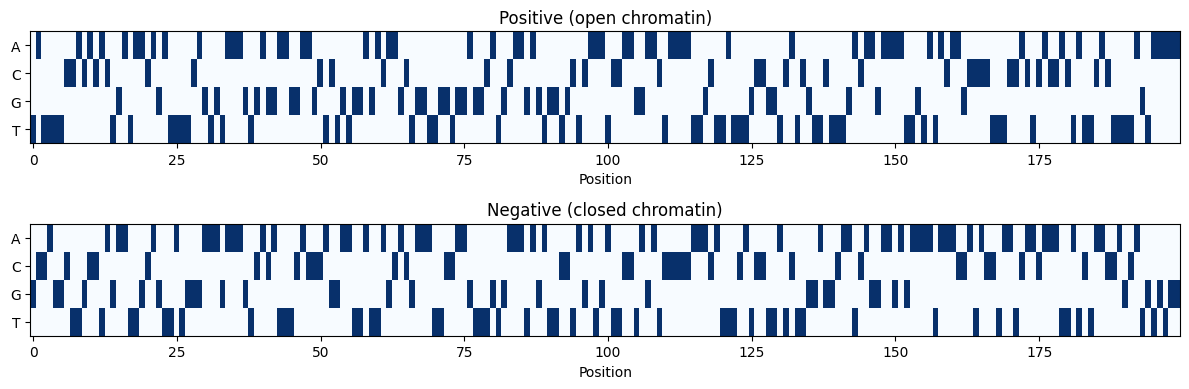

In [18]:
# Sanity check — visualize one positive and one negative sequence
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 4))
bases = ['A', 'C', 'G', 'T']

for idx, (ax, label) in enumerate(zip(axes, ['Positive (open chromatin)', 'Negative (closed chromatin)'])):
    seq_idx = 0 if idx == 0 else len(X_pos)
    im = ax.imshow(X[seq_idx], aspect='auto', cmap='Blues', interpolation='none')
    ax.set_yticks([0,1,2,3])
    ax.set_yticklabels(bases)
    ax.set_xlabel('Position')
    ax.set_title(label)

plt.tight_layout()
plt.savefig('~/figures/onehot_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sanity check done!')